Размер выборки: N = 50
Уровень шума: sigma = 0.2
Истинная функция: f(x) = exp(-x²) - exp(-(x-2)²/8)


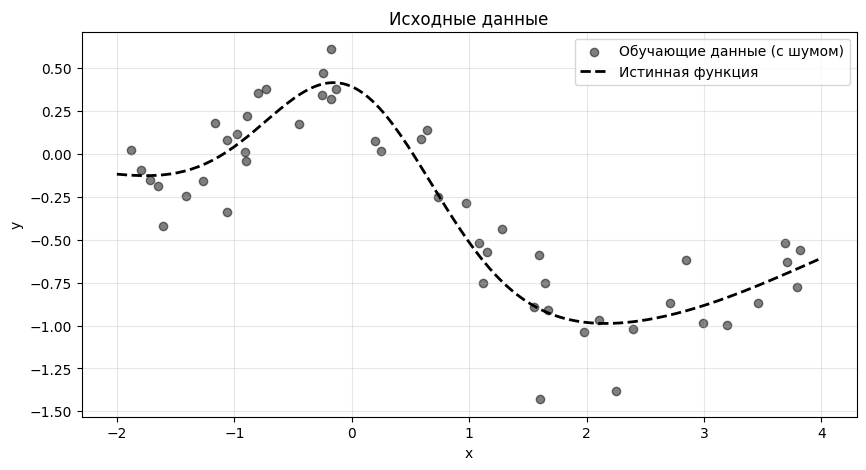

In [2]:
# Непараметрическая регрессия (Ядра и Gaussian Process)
# Цель: Сравнить ядерное сглаживание и гауссовские процессы

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N, sigma = 50, 0.2
x_min, x_max = -2, 4

def f_true(x):
    return np.exp(-x**2) - np.exp(-(x-2)**2 / 8)

X = np.sort(np.random.uniform(x_min, x_max, N))
y = f_true(X) + np.random.normal(0, sigma, N)

X_test = np.linspace(x_min, x_max, 200)
y_test_true = f_true(X_test)

print(f"Размер выборки: N = {N}")
print(f"Уровень шума: sigma = {sigma}")
print(f"Истинная функция: f(x) = exp(-x²) - exp(-(x-2)²/8)")

# Визуализация
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='black', alpha=0.5, label='Обучающие данные (с шумом)')
plt.plot(X_test, y_test_true, 'k--', lw=2, label='Истинная функция')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Исходные данные')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ЯДЕРНОЕ СГЛАЖИВАНИЕ (Nadaraya-Watson)
Оптимальная ширина окна (bandwidth): 0.1849
MSE на тестовой сетке: 0.007586


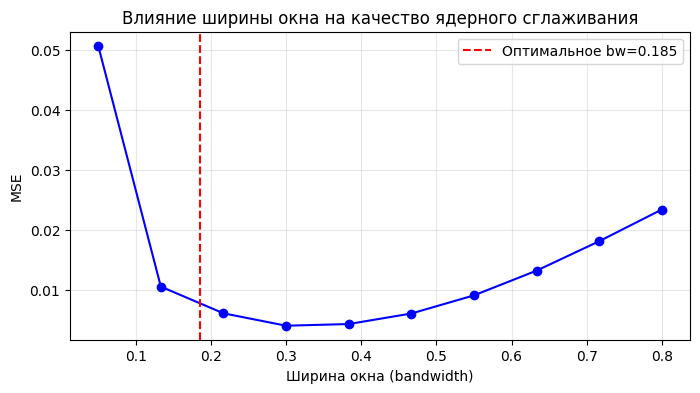

In [4]:
print("ЯДЕРНОЕ СГЛАЖИВАНИЕ (Nadaraya-Watson)")

kr = KernelReg(endog=y, exog=X, var_type='c', reg_type='ll', bw='cv_ls')
y_pred_kr, _ = kr.fit(X_test)

mse_kr = mean_squared_error(y_test_true, y_pred_kr)
print(f"Оптимальная ширина окна (bandwidth): {kr.bw[0]:.4f}")
print(f"MSE на тестовой сетке: {mse_kr:.6f}")

bandwidths = np.linspace(0.05, 0.8, 10)
mse_bandwidths = []

for bw in bandwidths:
    kr_temp = KernelReg(endog=y, exog=X, var_type='c', reg_type='ll', bw=[bw])
    pred_temp, _ = kr_temp.fit(X_test)
    mse_bandwidths.append(mean_squared_error(y_test_true, pred_temp))

plt.figure(figsize=(8, 4))
plt.plot(bandwidths, mse_bandwidths, 'bo-')
plt.axvline(kr.bw[0], color='red', linestyle='--', label=f'Оптимальное bw={kr.bw[0]:.3f}')
plt.xlabel('Ширина окна (bandwidth)')
plt.ylabel('MSE')
plt.title('Влияние ширины окна на качество ядерного сглаживания')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
print("ГАУССОВСКИЙ ПРОЦЕСС (GPR)")

kernels = {
    "RBF": C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=sigma**2),
    "Matern (ν=1.5)": C(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=sigma**2),
    "Matern (ν=2.5)": C(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=sigma**2)
}

best_gp = None
best_kernel_name = None
min_cv_mse = float('inf')
kf = KFold(n_splits=5)

print("Сравнение ядер через кросс-валидацию (5-fold):")

for kernel_name, kernel in kernels.items():
    cv_scores = []
    for train_idx, val_idx in kf.split(X):
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0)
        gp.fit(X[train_idx].reshape(-1, 1), y[train_idx])
        pred = gp.predict(X[val_idx].reshape(-1, 1))
        cv_scores.append(mean_squared_error(y[val_idx], pred))
    
    avg_mse = np.mean(cv_scores)
    print(f"  {kernel_name:<20}: CV MSE = {avg_mse:.6f}")
    
    if avg_mse < min_cv_mse:
        min_cv_mse = avg_mse
        best_kernel_name = kernel_name
        best_gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0)
        best_gp.fit(X.reshape(-1, 1), y)

print(f"\nЛучшее ядро: {best_kernel_name}")
print(f"Оптимальные гиперпараметры ядра:")
print(f"  {best_gp.kernel_}")

# Предсказание с доверительным интервалом
y_pred_gp, y_std_gp = best_gp.predict(X_test.reshape(-1, 1), return_std=True)
mse_gp = mean_squared_error(y_test_true, y_pred_gp)

print(f"\nMSE на тестовой сетке: {mse_gp:.6f}")

ГАУССОВСКИЙ ПРОЦЕСС (GPR)
Сравнение ядер через кросс-валидацию (5-fold):
  RBF                 : CV MSE = 0.044365
  Matern (ν=1.5)      : CV MSE = 0.057628
  Matern (ν=2.5)      : CV MSE = 0.049776

Лучшее ядро: RBF
Оптимальные гиперпараметры ядра:
  0.581**2 * RBF(length_scale=1.23) + WhiteKernel(noise_level=0.0349)

MSE на тестовой сетке: 0.002776


ВИЗУАЛИЗАЦИЯ И СРАВНЕНИЕ


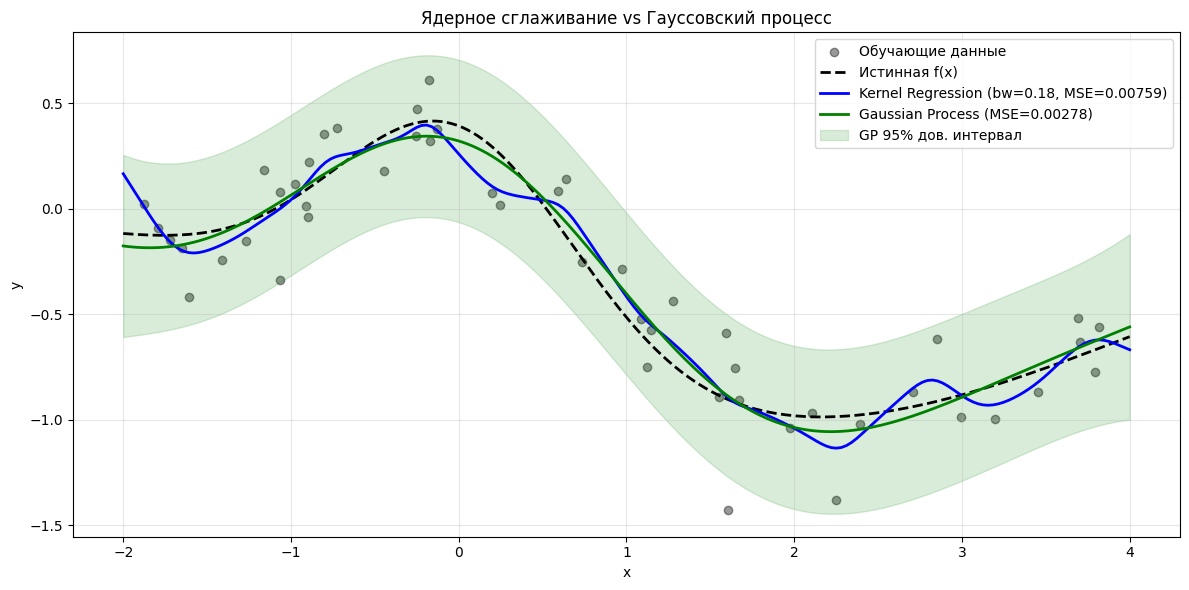

In [6]:
print("ВИЗУАЛИЗАЦИЯ И СРАВНЕНИЕ")

plt.figure(figsize=(12, 6))

plt.scatter(X, y, color='black', alpha=0.4, label='Обучающие данные')
plt.plot(X_test, y_test_true, 'k--', lw=2, label='Истинная f(x)')

plt.plot(X_test, y_pred_kr, 'b-', lw=2, 
         label=f'Kernel Regression (bw={kr.bw[0]:.2f}, MSE={mse_kr:.5f})')

plt.plot(X_test, y_pred_gp, 'g-', lw=2, 
         label=f'Gaussian Process (MSE={mse_gp:.5f})')

# Доверительный интервал GP (95%)
plt.fill_between(X_test, y_pred_gp - 1.96 * y_std_gp, 
                 y_pred_gp + 1.96 * y_std_gp,
                 color='green', alpha=0.15, label='GP 95% дов. интервал')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Ядерное сглаживание vs Гауссовский процесс')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

АНАЛИЗ НЕОПРЕДЕЛЁННОСТИ GP


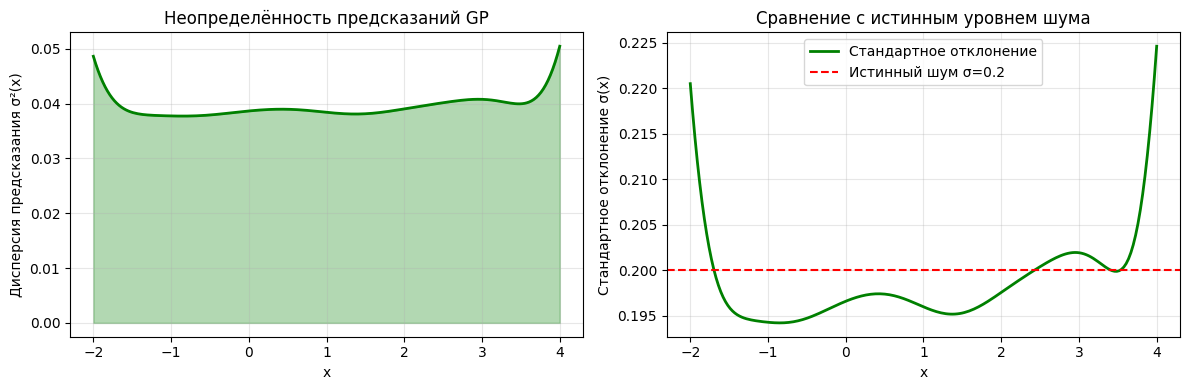

Анализ неопределённости:
  Среднее стандартное отклонение: 0.1987
  Истинный уровень шума: 0.2
  → GP немного недооценивает неопределённость


In [7]:
print("АНАЛИЗ НЕОПРЕДЕЛЁННОСТИ GP")

plt.figure(figsize=(12, 4))

# Подграфик 1: Дисперсия по x
plt.subplot(1, 2, 1)
plt.plot(X_test, y_std_gp**2, 'g-', lw=2)
plt.fill_between(X_test, 0, y_std_gp**2, color='green', alpha=0.3)
plt.xlabel('x')
plt.ylabel('Дисперсия предсказания σ²(x)')
plt.title('Неопределённость предсказаний GP')
plt.grid(True, alpha=0.3)

# Подграфик 2: Где GP уверен/не уверен
plt.subplot(1, 2, 2)
plt.plot(X_test, y_std_gp, 'g-', lw=2, label='Стандартное отклонение')
plt.axhline(y=sigma, color='red', linestyle='--', label=f'Истинный шум σ={sigma}')
plt.xlabel('x')
plt.ylabel('Стандартное отклонение σ(x)')
plt.title('Сравнение с истинным уровнем шума')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Анализ неопределённости:")
print(f"  Среднее стандартное отклонение: {np.mean(y_std_gp):.4f}")
print(f"  Истинный уровень шума: {sigma}")
if np.mean(y_std_gp) < sigma:
    print("  → GP немного недооценивает неопределённость")
else:
    print("  → GP хорошо оценивает уровень шума")

In [8]:
print("СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ ИЗ splines_gam")

methods_comparison = {
    "GAM (из дз4)": 0.00497,
    "Gaussian Process": mse_gp,
    "Kernel Regression": mse_kr,
    "Smoothing Spline (из дз4)": 0.01405,
    "B-Spline (Smooth) (из дз4)": 0.01135,
    "Ridge Polynomial (из дз4)": 0.09797
}

print(f"{'Метод':<30} | {'MSE':<10}")
print("-" * 42)
for name, mse in sorted(methods_comparison.items(), key=lambda x: x[1]):
    print(f"{name:<30} | {mse:.6f}")

СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ ИЗ splines_gam
Метод                          | MSE       
------------------------------------------
Gaussian Process               | 0.002776
GAM (из дз4)                   | 0.004970
Kernel Regression              | 0.007586
B-Spline (Smooth) (из дз4)     | 0.011350
Smoothing Spline (из дз4)      | 0.014050
Ridge Polynomial (из дз4)      | 0.097970


In [9]:
print("ИТОГОВЫЕ ВЫВОДЫ")

print("1. Сравнение ядерного сглаживания и GP:")
if mse_gp < mse_kr:
    print(f"   GP показал лучший результат (MSE={mse_gp:.6f} vs {mse_kr:.6f})")
else:
    print(f"   Kernel Regression показал лучший результат (MSE={mse_kr:.6f} vs {mse_gp:.6f})")

print("\n2. Преимущества Gaussian Process:")
print("   • Предоставляет доверительные интервалы (оценку неопределённости)")
print("   • Автоматически подбирает гиперпараметры ядра (длину корреляции, уровень шума)")
print("   • Является байесовским методом — менее склонен к переобучению")

print("\n3. Преимущества ядерного сглаживания:")
print("   • Проще в реализации и интерпретации")
print("   • Быстрее работает на больших данных")
print("   • Менее чувствителен к выбору ядра")

print("\n4. Сравнение с результатами дз4:")
print("   • GAM из дз4 показал MSE=0.00497 — это лучший результат среди всех методов")
print("   • GP (MSE={:.6f}) близок к GAM".format(mse_gp))
print("   • Ядерное сглаживание (MSE={:.6f}) уступает сплайнам и GAM".format(mse_kr))


ИТОГОВЫЕ ВЫВОДЫ
1. Сравнение ядерного сглаживания и GP:
   GP показал лучший результат (MSE=0.002776 vs 0.007586)

2. Преимущества Gaussian Process:
   • Предоставляет доверительные интервалы (оценку неопределённости)
   • Автоматически подбирает гиперпараметры ядра (длину корреляции, уровень шума)
   • Является байесовским методом — менее склонен к переобучению

3. Преимущества ядерного сглаживания:
   • Проще в реализации и интерпретации
   • Быстрее работает на больших данных
   • Менее чувствителен к выбору ядра

4. Сравнение с результатами дз4:
   • GAM из дз4 показал MSE=0.00497 — это лучший результат среди всех методов
   • GP (MSE=0.002776) близок к GAM
   • Ядерное сглаживание (MSE=0.007586) уступает сплайнам и GAM
